# 05 Walk-forward 回測

* 每季於公告日收盤依目標權重建倉，季內**買進持有**（權重隨價格漂移），下一季公告日收盤再平衡。
* 交易成本：買賣手續費 0.1425%、賣出證交稅 0.3%，依周轉率於建倉時扣除。
* 基準：等權重（同樣每季再平衡、計成本）、0050 ETF 買進持有。
* 事後 oracle（用持有期實際報酬與共變異數求出的最佳權重）**只用於診斷**，不參與排名。

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from qaportfolio.config import load_config
from qaportfolio.pipeline import schedule_from_cfg, load_prices
from qaportfolio import analysis, plotting
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 30)
cfg = load_config()
schedule = schedule_from_cfg(cfg)
SUMMARY = cfg["paths"]["results"] / "summary"

## 1. 累積報酬（主估計式，已扣交易成本）

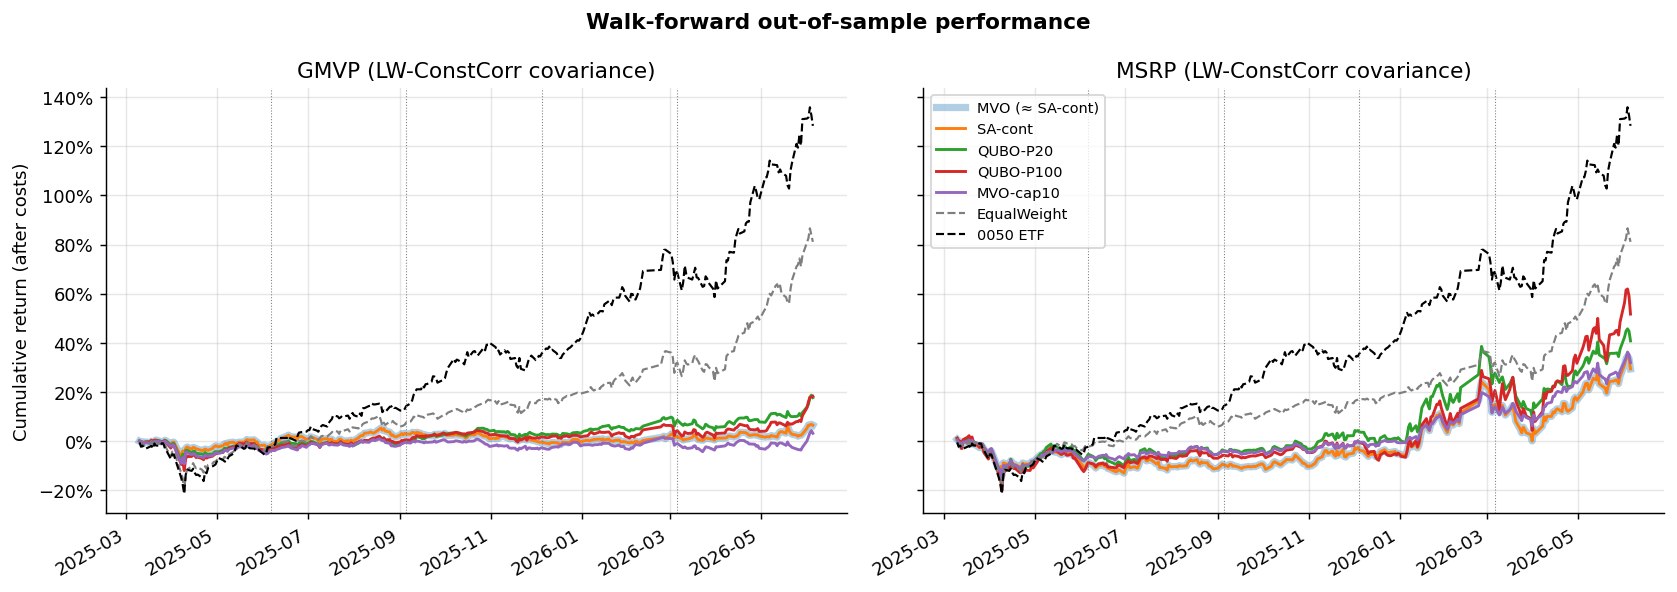

In [2]:
from IPython.display import Image
Image(filename=str(cfg["paths"]["results"] / "figures" / "nav_walkforward.png"))

## 2. 依方法彙總（5 種共變異數估計式的中位數）

In [3]:
pd.read_csv(SUMMARY / "by_method.csv", index_col=[0, 1])

Ann. Return  Ann. Vol  Sharpe  Max Drawdown  Beta (0050)  \
GMVP MVO                  0.0703    0.1174  0.6413       -0.0746       0.1807   
     MVO-round-P20        0.0447    0.1166  0.4292       -0.0726       0.1527   
     MVO-round-P100       0.0679    0.1176  0.6180       -0.0749       0.1788   
     SA-cont              0.0700    0.1174  0.6386       -0.0746       0.1807   
     QUBO-P20             0.1486    0.1333  1.1092       -0.0932       0.2848   
     QUBO-P100            0.1834    0.1461  1.2550       -0.1200       0.3750   
     MVO-cap10            0.0293    0.1325  0.2841       -0.0971       0.2757   
MSRP MVO                  0.1958    0.2471  0.8471       -0.1779       0.4941   
     MVO-round-P20        0.2214    0.2493  0.9272       -0.1720       0.5030   
     MVO-round-P100       0.1959    0.2467  0.8485       -0.1768       0.4911   
     SA-cont              0.1958    0.2471  0.8472       -0.1779       0.4941   
     QUBO-P20             0.2687    0.3023  0.9030       -0.2185       0.6256   
     QUBO-P100            0.3086    0.2958  1.0572       -0.2127       0.6933   
     MVO-cap10            0.2130    0.2081  1.0200       -0.1691       0.5156   

                     Avg Turnover  
GMVP MVO                   0.3423  
     MVO-round-P20         0.3503  
     MVO-round-P100        0.3452  
     SA-cont               0.3421  
     QUBO-P20              0.6363  
     QUBO-P100             0.5493  
     MVO-cap10             0.3470  
MSRP MVO                   0.8240  
     MVO-round-P20         0.8238  
     MVO-round-P100        0.8275  
     SA-cont               0.8240  
     QUBO-P20              0.8187  
     QUBO-P100             0.7502  
     MVO-cap10             0.6730

## 3. 基準

In [4]:
perf = pd.read_csv(SUMMARY / "performance.csv", index_col=0)
perf.loc[["EqualWeight", "0050 ETF"], ["Total Return", "Ann. Return", "Ann. Vol", "Sharpe", "Max Drawdown"]]

,Total Return,Ann. Return,Ann. Vol,Sharpe,Max Drawdown
EqualWeight,0.8108,0.6359,0.2311,2.2474,-0.2052
0050 ETF,1.2831,0.9824,0.2708,2.6654,-0.2108


## 4. 每季排名（同估計式、同組合類型下 7 種方法的平均名次，1 = 最好）

In [5]:
pd.read_csv(SUMMARY / "rank_table.csv", index_col=0)

,GMVP,MSRP
method,,
MVO,4.0800,4.9200
MVO-round-P20,5.0400,4.4800
MVO-round-P100,3.5600,4.5600
SA-cont,4.1200,4.7200
QUBO-P20,2.6000,3.1600
QUBO-P100,2.7200,2.6000
MVO-cap10,5.8800,3.5600


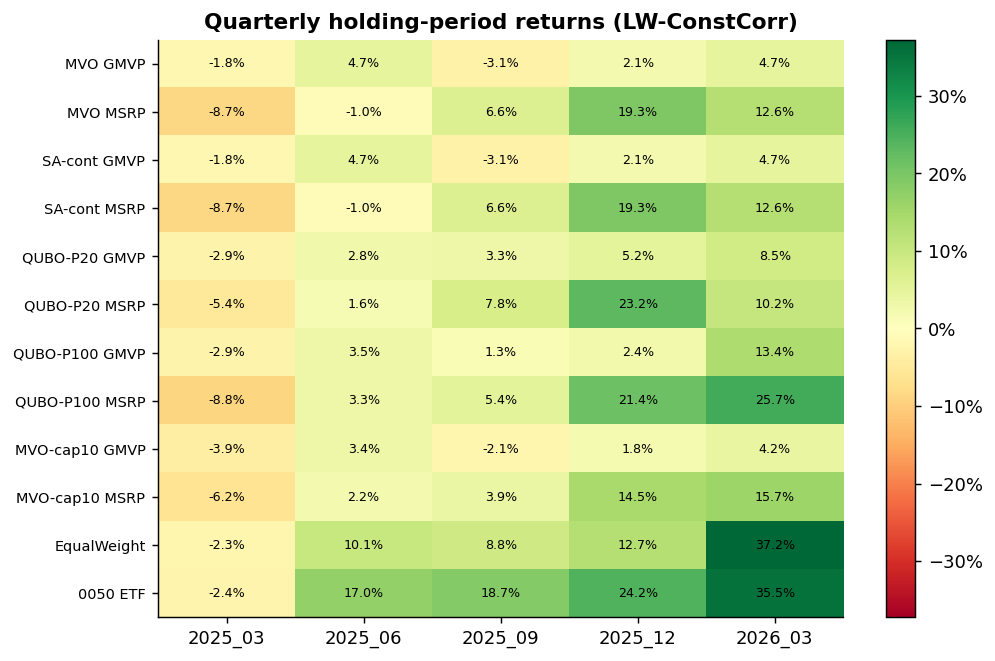

In [6]:
Image(filename=str(cfg["paths"]["results"] / "figures" / "quarterly_returns.png"))

## 5. 完整績效表

In [7]:
cols = ["method", "estimator", "portfolio", "Total Return", "Sharpe", "Ann. Vol", "Max Drawdown", "Avg Turnover"]
perf[perf["method"].isin(analysis.METHOD_ORDER)][cols].sort_values(["portfolio", "method", "estimator"])

,method,estimator,portfolio,Total Return,Sharpe,Ann. Vol,Max Drawdown,Avg Turnover
MVO|EWMA|GMVP,MVO,EWMA,GMVP,0.1185,0.8721,0.1139,-0.0750,0.4483
MVO|LW-ConstCorr|GMVP,MVO,LW-ConstCorr,GMVP,0.0645,0.5006,0.1174,-0.0697,0.3386
MVO|LW-Identity|GMVP,MVO,LW-Identity,GMVP,0.0841,0.6157,0.1206,-0.0829,0.3718
MVO|LW-SingleFactor|GMVP,MVO,LW-SingleFactor,GMVP,0.0855,0.6413,0.1167,-0.0745,0.3423
MVO|Sample|GMVP,MVO,Sample,GMVP,0.1171,0.8390,0.1178,-0.0746,0.3417
...,...,...,...,...,...,...,...,...
SA-cont|EWMA|MSRP,SA-cont,EWMA,MSRP,0.0913,0.4448,0.2147,-0.1582,0.8719
SA-cont|LW-ConstCorr|MSRP,SA-cont,LW-ConstCorr,MSRP,0.2935,0.9586,0.2571,-0.1945,0.8169
SA-cont|LW-Identity|MSRP,SA-cont,LW-Identity,MSRP,0.2806,0.9249,0.2575,-0.1921,0.8026
SA-cont|LW-SingleFactor|MSRP,SA-cont,LW-SingleFactor,MSRP,0.2260,0.8271,0.2386,-0.1719,0.8240


## 6. 與事後 oracle 權重的距離（L1，診斷用）

In [8]:
pd.read_csv(SUMMARY / "oracle_distance.csv", index_col=0)

,GMVP,MSRP
method,,
MVO,1.1381,1.8219
MVO-cap10,1.2746,1.6664
MVO-round-P100,1.1401,1.8234
MVO-round-P20,1.1567,1.8242
QUBO-P100,1.2989,1.7522
QUBO-P20,1.3194,1.8189
SA-cont,1.1381,1.8219


## 解讀

1. **被動基準大勝**：研究期間 0050 上漲 128%，等權重與 0050 的 Sharpe（2.25、2.67）遠高於任何最佳化組合。LSTM 的 μ 與實際持有期報酬的排序相關平均只有 0.02，最佳化主要是在放大雜訊。
2. **QUBO 的樣本外 Sharpe 高於 MVO，但可由 beta 解釋**：QUBO 組合較分散、對 0050 的 beta 較高（GMVP 0.37 vs 0.18；MSRP 0.69 vs 0.49），在多頭市場中自然得到較高報酬。以 GMVP 的本意（低波動）衡量，MVO 的樣本外波動與最大回撤反而較低。
3. **顯式正則化**：MVO 加 10% 權重上限後，MSRP 的 Sharpe（1.02）與 QUBO-P100（1.06）相當，且風險更低；GMVP 加上限則沒有改善，顯示 QUBO-GMVP 的「優勢」來自沒能壓低波動所保留的市場曝險。
4. **連續 SA ≈ MVO、四捨五入 ≈ MVO**：連續空間的退火能找到最佳解；離散化本身幾乎不改變組合。

5 季全落在單一多頭行情，這些差異都不足以下統計結論；它們說明的是「解的品質」與「投資績效」可能脫鉤，而脫鉤的原因需要以 beta、集中度等因素拆解，而非直接歸功於求解器。